In [ ]:
pip install pandas numpy scikit-learn tensorflow joblib

In [ ]:
#Random Seed Initialization for Reproducibility
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
#Load and Inspect the Household Power Consumption Dataset
import pandas as pd

# change the path if needed
file_path = "/content/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    low_memory=False,
    na_values=['?']
)

print(df.head())
print(df.shape)


         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
(522245, 9)


In [ ]:
# combine Date + Time
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H:%M:%S')

df = df.drop(columns=['Date', 'Time'])

# set index
df = df.set_index('DateTime')

# make them numeric
df = df.astype(float)

print(df.dtypes)
print(df.index.min(), df.index.max())

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
2006-12-16 17:24:00 2007-12-14 09:28:00


In [ ]:
# hourly mean
df_h = df.resample('H').mean()

print(df_h.shape)
df_h.head()

(8705, 7)


/tmp/ipython-input-2106436689.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_h = df.resample('H').mean()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [ ]:
#Data Cleaning – Handle Missing Values
df_h = df_h.interpolate(method='time')
df_h = df_h.dropna()
df_h.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


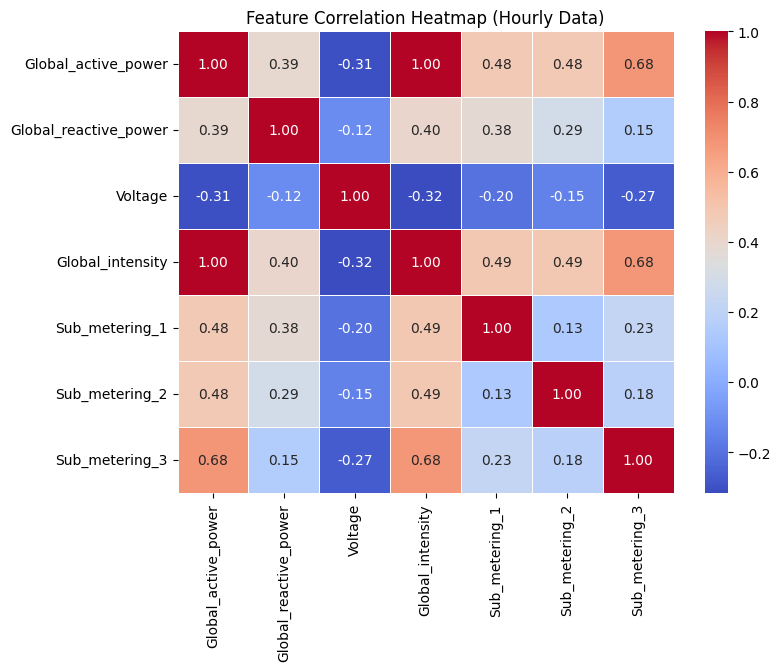

In [ ]:
# Correlation Heatmap of Energy Consumption Features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df_h.corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Hourly Data)")
plt.show()

In [ ]:
# Feature Engineering – Creating Lag Features for Target Variable
data = df_h.copy()

# target column
target_col = 'Global_active_power'

# create a few lag features for the target
for i in range(1, 4):
    data[f'gap_lag_{i}'] = data[target_col].shift(i)

# drop first few NaNs created by shift
data = data.dropna()

print(data.head())

                     Global_active_power  Global_reactive_power     Voltage  \
DateTime                                                                      
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   
2006-12-16 22:00:00             2.200133               0.056167  238.760000   
2006-12-16 23:00:00             2.061600               0.071433  240.619667   
2006-12-17 00:00:00             1.882467               0.102433  240.961833   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
DateTime                                                                
2006-12-16 20:00:00         13.916667             0.0        0.000000   
2006-12-16 21:00:00         13.046667             0.0        0.416667   
2006-12-16 22:00:00          9.523333             0.0        0.133333   
2006-12-16 23:00:00          8.896667             0.0        0.083333   
2006-12-

In [ ]:
# features and target
X_all = data.drop(columns=[target_col])
y_all = data[target_col]

# 80% train, 20% test
split_idx = int(len(data) * 0.8)

X_train_raw = X_all.iloc[:split_idx]
y_train = y_all.iloc[:split_idx]

X_test_raw = X_all.iloc[split_idx:]
y_test = y_all.iloc[split_idx:]

len(X_train_raw), len(X_test_raw)

(6961, 1741)

In [ ]:
# Baseline model: Random Forest on lagged/tabular data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

rf_base = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_raw, y_train)

rf_pred = rf_base.predict(X_test_raw)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Baseline Random Forest Performance")
print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")

Baseline Random Forest Performance
MAE : 0.0137
RMSE: 0.0191


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE

rf = RandomForestRegressor(n_estimators=120, random_state=42)

rfe = RFE(
    estimator=rf,
    n_features_to_select=8
)
rfe.fit(X_train_raw, y_train)

selected_mask = rfe.support_
selected_features = X_train_raw.columns[selected_mask].tolist()
print("✅ RFE selected the following features (in order):")
for i, feat in enumerate(selected_features, start=1):
    print(f"{i}. {feat}")


✅ RFE selected the following features (in order):
1. Global_reactive_power
2. Voltage
3. Global_intensity
4. Sub_metering_1
5. Sub_metering_2
6. Sub_metering_3
7. gap_lag_1
8. gap_lag_3


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()

# fit on TRAIN only
X_train_scaled = scaler.fit_transform(X_train_raw[selected_features])
X_test_scaled  = scaler.transform(X_test_raw[selected_features])

# save scaler
joblib.dump(scaler, 'scaler.pkl')

# also save features
import json
json.dump(selected_features, open('selected_features.json', 'w'))

In [ ]:
import numpy as np

def make_sequences(X_scaled, y_series, window=24):
    Xs, ys = [], []
    for i in range(len(X_scaled) - window):
        Xs.append(X_scaled[i:i+window])
        ys.append(y_series.iloc[i+window])
    return np.array(Xs), np.array(ys)

WINDOW = 24

X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train, WINDOW)
X_test_seq,  y_test_seq  = make_sequences(X_test_scaled, y_test, WINDOW)

X_train_seq.shape, y_train_seq.shape

((6937, 24, 8), (6937,))

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

n_features = len(selected_features)

model = Sequential()
model.add(LSTM(64, input_shape=(WINDOW, n_features)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

model.save('lstm_energy.h5')

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.9674 - mae: 0.7394 - val_loss: 0.7259 - val_mae: 0.7146
Epoch 2/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.5666 - mae: 0.5710 - val_loss: 0.5725 - val_mae: 0.5849
Epoch 3/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4750 - mae: 0.5030 - val_loss: 0.5019 - val_mae: 0.5365
Epoch 4/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4319 - mae: 0.4705 - val_loss: 0.4648 - val_mae: 0.5094
Epoch 5/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.4022 - mae: 0.4556 - val_loss: 0.4299 - val_mae: 0.4871
Epoch 6/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3893 - mae: 0.4458 - val_loss: 0.4237 - val_mae: 0.4916
Epoch 7/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3735 - mae: 0.4344 - val_loss: 0.3974 - val_mae: 0.4560
Epoch 8/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.3742 - mae: 0.4305 - val_loss: 0.3948 - val_mae: 0.4535
Epoch 9/25
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 80.2 MB/s eta 0:00:00
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
📈 Model Performance Metrics
----------------------------
Mean Absolute Error (MAE): 0.4294
Root Mean Squared Error (RMSE): 0.6366
R² Score: 0.6258
Mean Absolute Percentage Error (MAPE): 47.42%


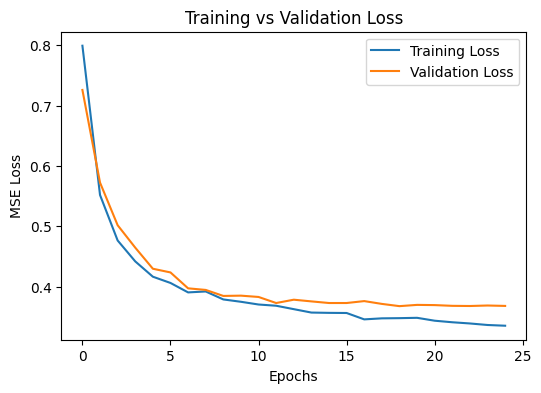

In [ ]:
# 📦 Install / import dependencies
!pip install -U scikit-learn --quiet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 🧠 Generate predictions
y_pred = model.predict(X_test_seq).flatten()

# 📊 Calculate metrics (manual sqrt for RMSE so it's version-safe)
mae  = mean_absolute_error(y_test_seq, y_pred)
mse  = mean_squared_error(y_test_seq, y_pred)
rmse = np.sqrt(mse)                # ✅ works on all sklearn versions
r2   = r2_score(y_test_seq, y_pred)
mape = np.mean(np.abs((y_test_seq - y_pred) / y_test_seq)) * 100

# 🖨️ Print all metrics
print("📈 Model Performance Metrics")
print("----------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# 📈 Plot 2: Training & Validation Loss (if 'history' exists)
if 'history' in locals():
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()

In [ ]:
# Comparison between Baseline RF and LSTM model
print("\n Comparison (Baseline vs LSTM)")
print(f"RF MAE   : {rf_mae:.4f}")
print(f"LSTM MAE : {mae:.4f}")
print(f"RF RMSE  : {rf_rmse:.4f}")
print(f"LSTM RMSE: {rmse:.4f}")


 Comparison (Baseline vs LSTM)
RF MAE   : 0.0137
LSTM MAE : 0.4294
RF RMSE  : 0.0191
LSTM RMSE: 0.6366


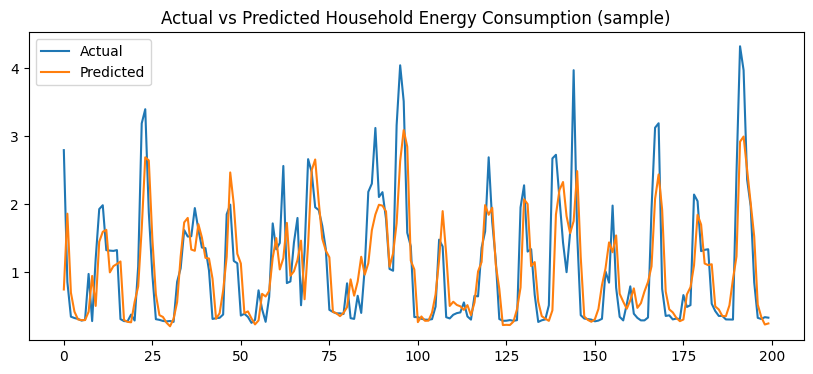

In [ ]:
# 📊 Plot 1: Actual vs Predicted (sample)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test_seq[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Household Energy Consumption (sample)')
plt.show()

In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# 1. load model WITHOUT compiling
model = load_model('lstm_energy.h5', compile=False)

# 2. load scaler + selected features
scaler = joblib.load('scaler.pkl')
features = json.load(open('selected_features.json'))

# 3. take last 24 rows from your processed dataframe `data`
WINDOW = 24
last_24 = data[features].tail(WINDOW)

# 4. scale
last_24_scaled = scaler.transform(last_24)

# 5. reshape to (1, window, n_features)
X_input = last_24_scaled.reshape(1, WINDOW, len(features))

# 6. predict
pred_next = model.predict(X_input)[0][0]
print("Predicted next-hour Global_active_power:", pred_next)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
Predicted next-hour Global_active_power: 1.3415812
